# NASDAQ-100 Microstructure: Feasibility Analysis

Before building a trading strategy it is worth asking whether the data can support one at all.
This notebook does that and nothing else: it fits no model and makes no forecast.

The strategy being checked is described in `config/setup.yaml`. It trades the constituents of the
NASDAQ-100 index, sorts them every fifteen minutes, and holds the ones at each end of that
ordering until the next sort. That file says which names it trades, which of them are cheap enough
to be worth holding, how often it changes positions, what a trade costs, and how the history is
divided between designing the strategy and testing it. This notebook checks each of those
assumptions against the data and reports what it finds.

The difficulty here is cost. At a fifteen-minute horizon a price move and the cost of capturing
it are the same order of magnitude, so a cost figure that is wrong by a factor of two changes the
answer. That is why more of this notebook is spent measuring cost than on anything else.

## Learning objectives

By the end of this notebook you will be able to:

- Turn a quoted bid-ask spread into a round-trip cost per symbol, and see why one average cost
  describes neither end of a cross-section
- Count how many names a strategy is allowed to hold at each moment it rebalances, and compare
  that against the number its portfolio grid asks for
- Compare price moves against cost when cost differs by symbol, by scaling each move by the cost
  of the symbol it happened in
- Measure whether the last price move says anything about the next one, computing the correlation
  inside each symbol rather than across symbols stacked into one series
- Check that a walk-forward split of the history fits the sample available and leaves the test
  period unread

## Book reference

Chapter 6, Sections 6.2-6.6. This notebook reads AlgoSeek minute bars and `config/setup.yaml`,
and writes the per-symbol cost profile that the backtest later charges itself.

## Prerequisites

None beyond what the sections below define. A reader who has not worked with quote data or split
a sample for walk-forward evaluation will find both explained where they are first used.

In [1]:
"""NASDAQ-100 Microstructure Case Study - Feasibility Analysis."""

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_nasdaq100_bars
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "nasdaq100_microstructure"
START_DATE = "2020-01-01"
MAX_SYMBOLS = 0  # 0 loads the declared universe; a positive value takes a deterministic subset

## Configuration

Everything the strategy assumes is declared in `config/setup.yaml`, and this notebook reads those
values rather than repeating them, so the two can never disagree. Four groups of settings matter
here, and each one decides something the sections below test.

**How the history is divided.** The sample runs from the start of 2020 to the end of 2021. The
last six months are the *holdout*: a stretch of history that is not looked at while the strategy
is being designed, so that when it is finally evaluated there, the result is not a rehearsal of
choices already tuned on the same data. `load_bars` below stops every frame short of
`holdout_start`, so no measurement in this notebook can see it.

**What the strategy trades.** `setup.yaml` names the index constituents, and then names a smaller
set again under `universe.cost_feasible`: the subset cheap enough to trade at this cadence,
frozen separately for the validation period and for the holdout. That second list is the
eligibility rule of this case study, and Sections B.2 and B.5 are drawn on it rather than on the
full roster. The strategy holds both ends of its ranking, up to 20 names per side, so at least 40
eligible names have to be quoting whenever it rebalances.

The roster itself follows one rule: **a symbol enters the universe only if it contributes at
least one session before `holdout_start`.** The archive carries more names than that. Some first
quote inside the holdout, and a name that appears only there cannot be fit on, has no spread in
the pre-holdout liquidity profile this notebook writes, and would therefore be traded in a
holdout backtest at a cost that was never measured for it. Section B.1 asserts the declared list
against the archive in both directions, so a delivery that adds or drops a name stops the
notebook rather than quietly changing every cross-sectional statistic below.

**When it is allowed to act.** `decision.bar_frequency` places a decision at the close of every
fifteen-minute bar, and `execution_delay` puts the resulting trade in the following bar. Scoring
a bar and trading at that same bar's close would let the strategy trade on a price it has already
used, which is why the delay is declared rather than assumed.

**What a trade is assumed to cost.** Two charges: a commission per share, and half the quoted gap
between the highest bid and the lowest offer, paid on each side of a round trip. Both are quoted in
dollars, so Section B.3 converts them into basis points, which is the only form in which they can
be compared against a price move.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
DECLARED_SYMBOLS = set(SETUP["universe"]["symbols"])
BREADTH_FLOOR = 2 * max(max(grid) for grid in SETUP["backtest"]["sweep"]["top_k_grid"].values())
PER_SHARE_USD = float(SETUP["costs"]["per_share"])
FRICTION_FLOOR_BPS = float(SETUP["costs"]["friction_floor_bps"])
COST_FEASIBLE = SETUP["universe"]["cost_feasible"]["validation"]
CADENCE = f"{SETUP['decision']['bar_frequency'].split('_')[0]}m"
LABEL_BUFFER = SETUP["labels"]["buffer"]
# The outcome horizons, not the purge buffers. They differ by one bar here - the label
# reads a quote one bar past the horizon it names - and reading the buffers would put
# 6, 16 and 61 minutes on this figure's axis under labels called 5, 15 and 60.
HORIZONS = sorted({int(h.rstrip("min")) for h in SETUP["labels"]["horizons"].values()})
WINDOW = {
    "start_date": START_DATE,
    "end_date": HOLDOUT_START,
    "max_symbols": MAX_SYMBOLS,
    "symbols": sorted(DECLARED_SYMBOLS),
}

print(f"Sample: {START_DATE} to {HOLDOUT_END}")
print(f"  Development period, used everywhere below:  {START_DATE} to {HOLDOUT_START}")
print(f"  Holdout, not read by this notebook:         {HOLDOUT_START} to {HOLDOUT_END}")
print(f"Universe: {len(DECLARED_SYMBOLS)} index constituents declared")
print(
    f"  {len(COST_FEASIBLE)} of them are frozen as cheap enough to trade in validation, and up to "
    f"{BREADTH_FLOOR // 2} are held per side, so at least {BREADTH_FLOOR} must be quoting at a "
    f"decision bar to fill both legs"
)
print(f"Decision bars: every {CADENCE}, with the trade placed in the following bar")
print(
    f"Assumed cost: ${PER_SHARE_USD} per share in commission, plus half the quoted spread on each "
    f"side, against a declared friction floor of {FRICTION_FLOOR_BPS:.0f} bps"
)
print(
    f"Forecast horizons: {', '.join(f'{h} minutes' for h in HORIZONS)} ahead; "
    f"{PRIMARY_LABEL.rsplit('_', 1)[1]} is the primary label and its {LABEL_BUFFER} buffer sets "
    f"the gap that separates training from validation"
)

Sample: 2020-01-01 to 2021-12-31
  Development period, used everywhere below:  2020-01-01 to 2021-07-01
  Holdout, not read by this notebook:         2021-07-01 to 2021-12-31
Universe: 115 index constituents declared
  50 of them are frozen as cheap enough to trade in validation, and up to 20 are held per side, so at least 40 must be quoting at a decision bar to fill both legs
Decision bars: every 15m, with the trade placed in the following bar
Assumed cost: $0.0035 per share in commission, plus half the quoted spread on each side, against a declared friction floor of 5 bps
Forecast horizons: 5 minutes, 15 minutes, 60 minutes ahead; 15m is the primary label and its 16min buffer sets the gap that separates training from validation


In [4]:
def load_bars(frequency: str = "1m") -> pl.DataFrame:
    """Quoted bars over the development window, with the quote midpoint attached."""
    return (
        load_nasdaq100_bars(frequency=frequency, include_quotes=True, **WINDOW)
        .filter(
            pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_datetime(),
            pl.col("bid_close") > 0,
            pl.col("ask_close") >= pl.col("bid_close"),
        )
        .select(
            "timestamp",
            "symbol",
            "close",
            session=pl.col("timestamp").dt.date(),
            mid=(pl.col("bid_close") + pl.col("ask_close")) / 2,
            half_spread_usd=(pl.col("ask_close") - pl.col("bid_close")) / 2,
        )
        .sort(["symbol", "timestamp"])
    )

## A. Orientation

### What the data is, and the two prices in it

At any moment a listed stock has two prices, not one. The *bid* is the highest price anyone has
publicly offered to buy at; the *offer*, or ask, is the lowest price anyone has offered to sell
at. Together they are the *quote*, and the feed that consolidates them across US exchanges is
called the NBBO, for national best bid and offer. Anyone buying immediately pays the offer and
anyone selling immediately receives the bid, so the gap between them - the *spread* - is what it
costs to change your mind straight away, and half of it is the charge attributable to one side of
a trade.

The *midpoint* of the two is the closest thing to a single price the market has. It matters here
because the last traded price is not one: a print at the bid followed by a print at the offer
looks like a price move and is not, so a series of traded prices carries a sawtooth that the
midpoint does not. Every return below is a midpoint return, and every cost comes off the quote.

### Why ranking names every fifteen minutes is a strategy at all

The strategy does not take a view on the market. Every fifteen minutes it sorts the names it is
allowed to hold by some measure of their recent behaviour, buys the top of the ordering and sells
the bottom, and unwinds at the next sort. Holding both ends means the move common to the whole
market cancels, which is what makes the bet about the ordering rather than about direction.

What makes this hard is the arithmetic of the horizon. Over fifteen minutes a typical NASDAQ-100
name moves a few tens of basis points, and a round trip costs a few basis points. Those are close
enough that whether the strategy is viable at all depends on which names it trades, and that is
what Section B.3 measures.

### The three questions this notebook asks

1. **Does the universe exist when the strategy trades?** Positions change every fifteen minutes,
   so enough eligible names have to be quoting at each of those bars to fill both sides.
2. **Is a typical price move worth more than the cost of capturing it?** Cost here is measured per
   symbol rather than assumed, because a penny of spread is a very different charge on a $25 share
   than on a $500 one.
3. **Is there enough history to evaluate this honestly?** Enough to split into training and
   validation periods more than once, with the holdout left untouched.

## B. Universe and cost feasibility

### B.1 Load the data and look at the universe

The loader returns one row per symbol and minute, carrying the traded close and the bid and
offer quoted at the end of that minute. Two properties are checked before anything is computed:
that the declared roster is exactly the set of names the rule admits, and that no quote is
inverted or non-positive, since the midpoint of a crossed quote is not a price.

The first check runs in both directions. A declared name the archive never quotes would leave the
panel one column short of what every section below assumes; an archived name that quotes before
the holdout and is *not* declared would silently join every cross-section, every rank and the
liquidity profile without ever having been decided on. Comparing only the first direction is what
let a delivery of 123 symbols be read through a roster of 114.

In [5]:
eligible = (
    set(
        load_nasdaq100_bars(start_date=START_DATE, end_date=HOLDOUT_START, lazy=True)
        .filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_datetime())
        .select("symbol")
        .unique()
        .collect()["symbol"]
    )
    if not MAX_SYMBOLS
    else DECLARED_SYMBOLS
)
assert eligible == DECLARED_SYMBOLS, (
    f"declared but never quoted before {HOLDOUT_START}: {sorted(DECLARED_SYMBOLS - eligible)}; "
    f"quoted before {HOLDOUT_START} but not declared: {sorted(eligible - DECLARED_SYMBOLS)}"
)

minute_bars = load_bars()
print(
    f"{minute_bars['symbol'].n_unique()} symbols, {len(minute_bars):,} quoted minutes, "
    f"{minute_bars['timestamp'].min()} to {minute_bars['timestamp'].max()}"
)

115 symbols, 15,041,235 quoted minutes, 2020-01-02 09:30:00 to 2021-06-30 15:59:00


A hundred-odd tickers are a list, not a description. What separates them for this strategy is
price level, because the spread is quoted in cents: the same one-cent gap is four basis points on
a $25 share and half a basis point on a $200 one. The table below groups the universe into price
bands and shows, for each, how wide the quote typically is in cents, what that comes to in basis
points, and how many of the band's names survived into the frozen eligible list.

Read the two spread columns against each other. The one in cents rises steeply with price, which
is what a fixed tick size and a wider absolute quote on an expensive share produce. The one in
basis points - the only one comparable against a return - does not simply fall to compensate: it
is lowest in the middle of the price range and higher at both ends. Price level is therefore part
of what makes a name expensive to trade and not the whole of it, which is why Section B.3
measures each symbol separately instead of scaling one average by price.

In [6]:
PRICE_BANDS = [50.0, 100.0, 250.0]
band_label = (
    pl.when(pl.col("mean_price") < PRICE_BANDS[0])
    .then(pl.lit(f"1  under ${PRICE_BANDS[0]:.0f}"))
    .when(pl.col("mean_price") < PRICE_BANDS[1])
    .then(pl.lit(f"2  ${PRICE_BANDS[0]:.0f} to ${PRICE_BANDS[1]:.0f}"))
    .when(pl.col("mean_price") < PRICE_BANDS[2])
    .then(pl.lit(f"3  ${PRICE_BANDS[1]:.0f} to ${PRICE_BANDS[2]:.0f}"))
    .otherwise(pl.lit(f"4  over ${PRICE_BANDS[2]:.0f}"))
)
by_symbol = minute_bars.group_by("symbol").agg(
    mean_price=pl.col("close").mean(),
    median_half_spread_usd=pl.col("half_spread_usd").median(),
    median_half_spread_bps=(pl.col("half_spread_usd") / pl.col("mid") * 1e4).median(),
)
bands = (
    by_symbol.with_columns(band_label.alias("price_band"))
    .group_by("price_band")
    .agg(
        symbols=pl.len(),
        eligible=pl.col("symbol").is_in(COST_FEASIBLE).sum(),
        median_price_usd=pl.col("mean_price").median().round(0),
        median_half_spread_cents=(pl.col("median_half_spread_usd") * 100).median().round(2),
        median_half_spread_bps=pl.col("median_half_spread_bps").median().round(2),
    )
    .sort("price_band")
)
with pl.Config(tbl_rows=bands.height, tbl_cols=bands.width, tbl_width_chars=200):
    display(bands)

price_band,symbols,eligible,median_price_usd,median_half_spread_cents,median_half_spread_bps
str,u32,u32,f64,f64,f64
"""1 under $50""",18,10,37.0,0.5,1.84
"""2 $50 to $100""",23,18,79.0,1.0,1.29
"""3 $100 to $250""",45,15,148.0,4.0,2.98
"""4 over $250""",29,7,434.0,18.0,3.92


### B.2 How many names the strategy is allowed to hold when it rebalances

A single count over the whole sample would hide the question a strategy of this shape has to
answer, which is how many names it can choose between *at the moment it has to choose*. Two
counts are drawn: the declared universe, and the eligible subset `universe.cost_feasible` freezes
for the validation period. The second is the one that binds, because the strategy may only hold
those names. The reference line is what the largest entry in `backtest.sweep.top_k_grid` needs:
twenty positions on each side, so forty eligible names quoting at once.

Where the eligible count dips below that line the strategy could not have filled the book it
declares. The printout after the figure names the dates on which that happens, so a reader can
check whether they are a real thinning of the market or an artefact of how the bars are cut.

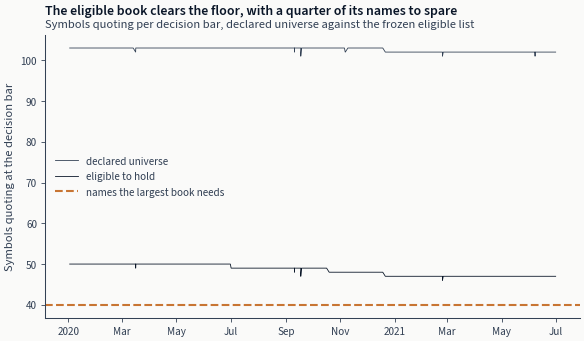

Declared 101 to 103 per bar, cost-feasible 46 to 50; under the floor of 40 on 0 of 9,778 bars


In [7]:
decision_bars = load_bars(CADENCE)
breadth = (
    decision_bars.group_by("timestamp")
    .agg(declared=pl.len(), screened=pl.col("symbol").is_in(COST_FEASIBLE).sum())
    .sort("timestamp")
)
thin = breadth.filter(pl.col("screened") < BREADTH_FLOOR)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ts = breadth["timestamp"]
ax.plot(ts, breadth["declared"], color=COLORS["neutral"], lw=0.6, label="declared universe")
ax.plot(ts, breadth["screened"], color=COLORS["blue"], lw=0.6, label="eligible to hold")
ax.axhline(
    BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="names the largest book needs"
)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set_ylabel("Symbols quoting at the decision bar")
ax.legend(frameon=False, fontsize=8, loc="center left")
add_message_title(
    ax,
    "The eligible book clears the floor, with a quarter of its names to spare",
    subtitle="Symbols quoting per decision bar, declared universe against the frozen eligible list",
)
show_with_alt(
    fig,
    "Two lines across the sample: the count of declared names quoting at each decision bar, and the count from the frozen eligible list, against a horizontal line at the forty names the largest book has to fill.",
)
_thin_dates = thin["timestamp"].dt.date().unique().sort().to_list()
print(
    f"Declared {breadth['declared'].min()} to {breadth['declared'].max()} per bar, cost-feasible "
    f"{breadth['screened'].min()} to {breadth['screened'].max()}; under the floor of "
    f"{BREADTH_FLOOR} on {len(thin)} of {len(breadth):,} bars"
    + (", all on " + ", ".join(str(d) for d in _thin_dates) if _thin_dates else "")
)

### B.3 What a round trip costs, symbol by symbol

`setup.yaml::costs` charges a per-share commission plus half the quoted spread on each side of a
trade. Both are dollar amounts, and a dollar amount cannot be compared against a return until it
is divided by a price: that is what the table in B.1 showed, and this section carries it through
to a single number per symbol. A *round trip* is buying and later selling, so both charges are
paid twice, and the result is expressed in basis points of the price traded.

The chart draws one bar per symbol, ordered from cheapest to dearest, so the shape of the
distribution is visible rather than summarized. Two reference lines are drawn on it: the median
across the universe, and `costs.friction_floor_bps`, the level `setup.yaml` declares as the
optimistic case. The names shaded dark are the eligible list frozen in `universe.cost_feasible`.
That list was selected on the same quantity but over a window ending before validation begins, so
the dark bars should sit at the cheap end without being exactly the leftmost fifty.

The whole universe is drawn here, unlike Sections B.2 and B.5, because the point of this figure is
to show where the eligibility rule cuts - which requires seeing what it cut away.

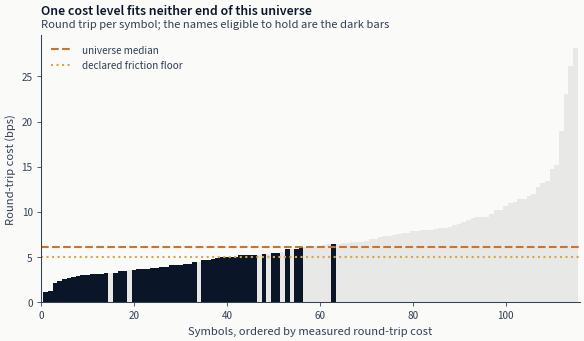

In [8]:
spread_bps = pl.col("half_spread_usd") / pl.col("mid") * 1e4
rt_cost = 2 * pl.col("median_half_spread_bps") + 2e4 * PER_SHARE_USD / pl.col("mean_price")
liquidity_profile = (
    minute_bars.group_by("symbol")
    .agg(
        median_half_spread_usd=pl.col("half_spread_usd").median(),
        median_half_spread_bps=spread_bps.median(),
        mean_price=pl.col("close").mean(),
    )
    .with_columns(rt_cost_bps_median=rt_cost)
    .sort("rt_cost_bps_median")
    .with_row_index("cost_rank", offset=1)
)
cost = liquidity_profile["rt_cost_bps_median"]
UNIVERSE_COST_BPS = float(cost.median())

tone = (COLORS["blue"], COLORS["silver_muted"])
bars = np.where(liquidity_profile["symbol"].is_in(COST_FEASIBLE), *tone)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(liquidity_profile["cost_rank"], cost, color=bars, width=1.0)
ax.axhline(UNIVERSE_COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.axhline(
    FRICTION_FLOOR_BPS, color=COLORS["amber"], ls=":", lw=1.5, label="declared friction floor"
)
ax.set_xlim(0, len(liquidity_profile) + 1)
ax.set_xlabel("Symbols, ordered by measured round-trip cost")
ax.set_ylabel("Round-trip cost (bps)")
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "One cost level fits neither end of this universe",
    subtitle="Round trip per symbol; the names eligible to hold are the dark bars",
)
show_with_alt(
    fig,
    "One bar per symbol, ordered from the tightest round-trip cost to the widest, with the eligible names drawn dark and horizontal lines at the universe median and at the declared friction floor.",
)

### B.4 Whether the last move says anything about the next

Rebalancing every fifteen minutes is only worth the trading it causes if something observed at one
decision bar still says something at the next. The cheapest thing to check is whether the most
recent move itself carries, and the statistic that answers it is *autocorrelation*: the
correlation between a series and the same series shifted back by a fixed number of bars, called
the lag.

Two choices about how it is computed change the answer. It is computed inside each symbol and then
averaged, because stacking every symbol into one series and correlating that would mostly measure
the points where one symbol's history ends and the next begins. And it is computed within a
session, over four lags only: further out most pairs would join the end of one trading day to the
start of the next, across a gap of seventeen hours the lag count does not know about.

The shaded band shows how much symbols differ from one another, and the horizontal strip is the
range within which a correlation is indistinguishable from zero at this sample size.

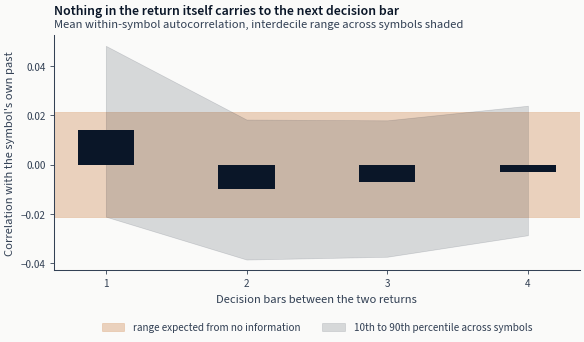

In [9]:
decision_returns = decision_bars.with_columns(
    ret=pl.col("mid").pct_change().over(["symbol", "session"])
).drop_nulls("ret")
acf = panel_acf(decision_returns, entity_col="symbol", value_col="ret", max_lags=4)[1:]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.axhspan(
    -acf["band"][0],
    acf["band"][0],
    color=COLORS["copper"],
    alpha=0.3,
    zorder=0,
    label="range expected from no information",
)
ax.fill_between(
    acf["lag"],
    acf["acf_p10"],
    acf["acf_p90"],
    color=COLORS["blue"],
    alpha=0.15,
    label="10th to 90th percentile across symbols",
)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.4)
ax.set_xticks(acf["lag"])
ax.set_xlabel("Decision bars between the two returns")
ax.set_ylabel("Correlation with the symbol's own past")
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18))
add_message_title(
    ax,
    "Nothing in the return itself carries to the next decision bar",
    subtitle="Mean within-symbol autocorrelation, interdecile range across symbols shaded",
)
show_with_alt(
    fig,
    "Autocorrelation of a symbol's return with its own past, one bar per lag in decision bars, with the interdecile range across symbols shaded behind the mean.",
)

That is a useful negative result rather than a discouraging one. It rules out the simplest
possible signal - buy what just went up - and says that anything predictive here has to come from
the fields the return summarises away, which is what the order-flow and quote features of
Chapter 8 are built from.

### B.5 Move scale against cost

The last question of this section is what fraction of price moves are larger than the cost of
capturing them. Costs differ across this universe by more than a factor of twenty, so a single
cost line drawn against raw returns would answer the question for no symbol in particular. Each
move is divided by the round trip of the symbol it happened in instead, which puts break-even at
one for every symbol at once and makes the horizons comparable.

The chart is an *exceedance curve*: at each multiple on the horizontal axis it shows the fraction
of moves at least that large. Reading up from the line at one gives the share of moves that would
have covered their own cost. The moves are unsigned, so this measures how far prices travel and
not how much of that travel a strategy could capture - the second is a forecasting question and
Chapter 7 is where it starts.

The population is the eligible list, the names `universe.cost_feasible` allows the strategy to
hold in validation. A move in a name the strategy may not hold is not an opportunity, and counting
it would overstate how often cost is cleared.

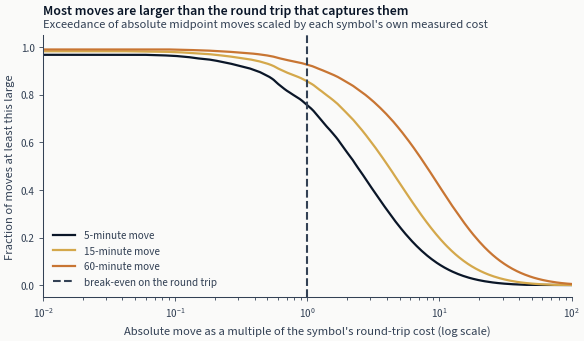

In [10]:
moves = (
    minute_bars.filter(pl.col("symbol").is_in(COST_FEASIBLE))
    .with_columns(
        (pl.col("mid").pct_change(h).over(["symbol", "session"]).abs() * 1e4).alias(f"h{h}")
        for h in HORIZONS
    )
    .join(liquidity_profile.select("symbol", "rt_cost_bps_median"), on="symbol")
    .with_columns((pl.col(f"h{h}") / pl.col("rt_cost_bps_median")).alias(f"m{h}") for h in HORIZONS)
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"], COLORS["copper"]), strict=True):
    multiple, fraction = exceedance_curve(moves[f"m{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-minute move")
ax.axvline(1, color=COLORS["neutral"], ls="--", lw=1.5, label="break-even on the round trip")
ax.set_xscale("log")
ax.set_xlim(0.01, 100)
ax.set_xlabel("Absolute move as a multiple of the symbol's round-trip cost (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Most moves are larger than the round trip that captures them",
    subtitle="Exceedance of absolute midpoint moves scaled by each symbol's own measured cost",
)
show_with_alt(
    fig,
    "Three curves, one per forecast horizon, giving the fraction of absolute midpoint moves at least as large as each multiple of the symbol's own round-trip cost, on a logarithmic axis with break-even marked at one.",
)

In [11]:
print(
    f"Round-trip cost across the {len(liquidity_profile)} declared symbols: {cost.min():.2f} to "
    f"{cost.max():.2f} bps, median {UNIVERSE_COST_BPS:.2f}"
)
print(f"Moves below are over the {moves['symbol'].n_unique()} names eligible to hold in validation")
for h in HORIZONS:
    med, share = moves.select(pl.col(f"h{h}").median(), (pl.col(f"m{h}") > 1).mean()).row(0)
    print(f"  {h:>2}-minute move: median {med:.1f} bps, clears its own round trip {share:.3f}")

Round-trip cost across the 115 declared symbols: 1.16 to 28.17 bps, median 6.16
Moves below are over the 50 names eligible to hold in validation
   5-minute move: median 9.1 bps, clears its own round trip 0.757
  15-minute move: median 15.8 bps, clears its own round trip 0.856
  60-minute move: median 30.6 bps, clears its own round trip 0.926


Measured round-trip cost across the 115 declared names runs from 1.16 bps on the tightest-quoted
to 28.17 bps on the widest, with a median of 6.16 bps - a spread of more than a factor of twenty,
which is why one cost level would not do. Over the 50 names the strategy is allowed to hold, the
median absolute midpoint move is 9.1 bps at 5 minutes, 15.8 bps at 15 and 30.6 bps at 60, and the
fraction of moves clearing the symbol's own round trip is 0.757, 0.856 and 0.926 at those
horizons. At the traded cadence a typical move is under three times the round trip, and a strategy
keeps only the part of it whose direction it called correctly.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.bar_frequency` rebalances on the fifteen-minute bar and
`execution_delay` puts the trade in the following one. B.5 prices that from both sides: a
shorter horizon clears the round trip less often, a longer one spends fewer decisions on the
same sample. Scoring a bar with its own close and trading there would restate the signal's
own price, so the delay is declared once here.

### C.2 Kill conditions

Three conditions would send this strategy back to the drawing board rather than forward. Each is
stated here and tested where its evidence exists, not in this notebook: no feature reaches a
correlation with future returns distinguishable from zero across the folds, which Chapter 8
measures; the expected gross edge stays below the round trip B.3 measured, which Chapter 17
prices; and the signal decays inside the one-bar execution delay, which Chapter 7 tests. They are
written down in advance so that the decision to abandon is made against a threshold rather than
against a disappointing result.

### C.3 Mapping class

`setup.yaml::mapping.class` ranks symbols at each decision bar and holds both ends of the
ordering. Two things make that possible here. These are large, heavily traded names, so the short
leg can be borrowed about as cheaply as the long leg can be bought, and holding both cancels the
move common to the whole market - which a score built from the cross-section has no claim to
predict in the first place.

## D. Walk-forward structure

### D.1 Effective sample size

A panel this size looks enormous - millions of rows - and that number is misleading. What
evaluation actually spends is decision bars, because a hundred symbols observed at the same
instant share whatever moved the market at that instant: the common part is one observation, not
a hundred. The count below is therefore the honest denominator for anything measured across the
cross-section, and it is three orders of magnitude smaller than the row count.

In [12]:
print(
    f"Decision bars {len(breadth):,} over {decision_bars['session'].n_unique():,} sessions "
    f"| symbols per decision bar {breadth['declared'].mean():.0f}"
)

Decision bars 9,778 over 377 sessions | symbols per decision bar 103


### D.2 Fold demonstration

A walk-forward split cuts the development period into consecutive blocks: a *training* window the
model is fitted on, then a *validation* window it is scored on, with the pair sliding forward to
make the next fold. Between the two sits a *purge gap*, a stretch dropped from both. It is needed
because a label is a statement about the future: a target computed at the last bar of training
resolves fifteen minutes later, and without the gap that resolution falls inside validation and
the score is partly a score on data the model was fitted on.

`generate_cv_splits` places those boundaries from the widths in `setup.yaml::evaluation` and the
gap from the label buffer, and the figure draws the boundaries it returned rather than recomputing
them, so the picture and the folds cannot disagree. It numbers folds chronologically, so fold 0 is
the earliest and the highest number ends against the holdout. The figure and the printout below
label each fold with that number, which is why the labels count up as the folds move forward;
every later stage prints the same ones.

The splitter is given the whole sample, holdout included, and applies the holdout boundary itself
from `evaluation.holdout_start`, which is what every later stage does - `02_labels` writes labels
across the full range and `05_evaluation` derives its folds from that frame. Handing the splitter
a frame that stops at the holdout instead shifts the first training bar of both folds by four
sessions, and the figure would then show a training window the pipeline never trains on. This is
the one place in the notebook that reads a timestamp from the holdout period; no price, quote or
return from it is loaded.

The gap drawn is the buffer for the primary label, `labels.buffer`. The longest declared variant,
`fwd_ret_60m`, resolves an hour out and carries its own wider buffer in `labels.variant_buffers`;
a fold built for that variant purges four bars rather than one.

One fold boundary here falls where a session ends, and the check below allows for it. A label in
this case study never crosses a session boundary - `02_labels` keys every window on the
symbol-session, so the last bars of a day carry no label at all. Where training stops on the final
bar of a session there is consequently nothing to purge: the bar has no forward window to leak.
The assertion tests the property that matters, which is that no labelled training bar resolves at
or after the first validation bar, rather than testing that a fixed number of bars was removed.

2 folds over 13,094 decision bars
  Fold 1 | train 2020-01-02 09:30:00 to 2020-06-29 15:45:00 | validate 2020-06-30 09:30:00 to 2020-12-29 15:30:00 | 0 bar purged; training ends on a session's last bar, which carries no label
  Fold 0 | train 2020-06-30 09:30:00 to 2020-12-29 15:15:00 | validate 2020-12-29 15:45:00 to 2021-06-30 15:45:00 | 1 bar purged


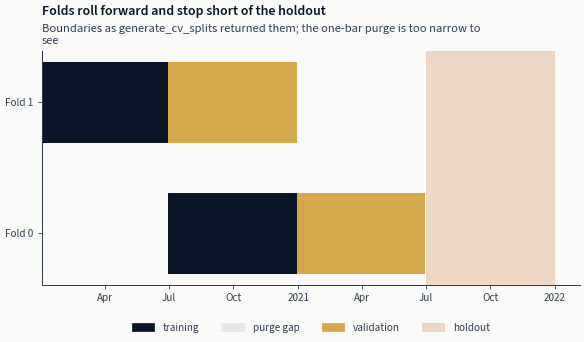

In [13]:
full_timeline = (
    load_nasdaq100_bars(
        frequency=CADENCE,
        include_quotes=False,
        start_date=START_DATE,
        end_date=HOLDOUT_END,
        max_symbols=MAX_SYMBOLS,
        symbols=sorted(DECLARED_SYMBOLS),
    )
    .select("timestamp")
    .unique()
    .sort("timestamp")
)
splits = generate_cv_splits(
    full_timeline,
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"
grid = full_timeline["timestamp"].to_numpy()
session_ends = set(
    full_timeline.group_by(pl.col("timestamp").dt.date().alias("session"))
    .agg(pl.col("timestamp").max())["timestamp"]
    .to_list()
)
print(f"{len(splits)} folds over {len(full_timeline):,} decision bars")
for split in sorted(splits, key=lambda s: s["train_start"]):
    train_end, val_start = split["train_end"], split["val_start"]
    purged = int(((grid > np.datetime64(train_end)) & (grid < np.datetime64(val_start))).sum())
    unlabelled = train_end in session_ends
    assert purged >= 1 or unlabelled, (
        f"training ends {train_end} mid-session with no bar purged before {val_start}"
    )
    why = "training ends on a session's last bar, which carries no label" if unlabelled else ""
    print(
        f"  Fold {split['fold']} | train {split['train_start']} to {train_end} | validate "
        f"{val_start} to {split['val_end']} | {purged} bar purged{'; ' + why if why else ''}"
    )

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
add_message_title(
    ax,
    "Folds roll forward and stop short of the holdout",
    subtitle="Boundaries as generate_cv_splits returned them; the one-bar purge is too narrow to see",
)
show_with_alt(
    fig,
    "Each fold drawn as a training span followed by a validation span, rolling forward through the sample and stopping before the holdout period begins.",
)

## E. Derived artifacts

This notebook writes one file, and it is written because two later steps read it.
`setup.yaml::costs.asset_spreads_source` names `liquidity_profile.parquet`, from which the cost
model joins `median_half_spread_usd` per symbol so that the backtest charges each name its own
measured spread rather than one average; and `_build_cost_feasible_universe.py` ranks on the same
column to freeze the eligible list that Sections B.2 and B.5 used.

In [14]:
profile_path = CASE_DIR / "liquidity_profile.parquet"
liquidity_profile.write_parquet(profile_path)
print(f"Written: {profile_path.name} ({len(liquidity_profile)} symbols)")

Written: liquidity_profile.parquet (115 symbols)


## F. Findings vs `setup.yaml`

Each declared setting is paired below with the evidence in this notebook that motivates it, and
with the condition under which a reader working on their own data would revise it.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.symbols` | B.2 breadth per decision bar | breadth falls under the positions the sweep asks for on either leg |
| `universe.cost_feasible` | B.3 cost ordering and where the eligible list cuts | the eligible names stop being the cheap end of the ordering |
| `costs.model` | B.3 measured per-symbol half-spread | one level fits the cross-section, or the vendor stops supplying quotes |
| `decision.bar_frequency` | B.4 persistence, B.5 clearance by horizon | a longer horizon clears cost often enough to pay for the decisions it gives up |
| `evaluation.n_splits` | D.1 decision bars, D.2 fold boundaries | the folds no longer fit the development window |

In [15]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, screened breadth "
    f"{breadth['screened'].min()} to {breadth['screened'].max()} | costs.model "
    f"{SETUP['costs']['model']}, measured round trip median "
    f"{UNIVERSE_COST_BPS:.2f} bps against a declared floor of {FRICTION_FLOOR_BPS:.0f} bps\n"
    f"decision.bar_frequency {SETUP['decision']['bar_frequency']} | labels.primary "
    f"{PRIMARY_LABEL} | evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated "
    f"{len(splits)}, last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 115, screened breadth 46 to 50 | costs.model per_share_plus_spread, measured round trip median 6.16 bps against a declared floor of 5 bps
decision.bar_frequency 15_minute | labels.primary fwd_ret_15m | evaluation.n_splits 2, generated 2, last validation ends 2021-06-30, holdout untouched


The declared universe carries 101 to 103 symbols per decision bar and the eligible book 46 to 50,
so the 40 the largest declared portfolio needs is available at every one of the 9,778 decision
bars. The measured round-trip median of 6.16 bps sits above the friction floor of 5 bps
`setup.yaml` declares, so that floor is the optimistic end of what this universe charges rather
than a typical case. Two folds are generated over 13,094 decision bars, training from 2020-01-02
and ending its last validation on 2021-06-30, with the holdout untouched.

## Key takeaways

1. **Measure cost per symbol wherever quotes exist.** A spread is a price in cents, so converting
   the universe at one average price misstates both ends of the ordering - and at an intraday
   horizon that error is the same size as the thing being measured.
2. **Scale each move by its own symbol's cost before comparing horizons**, which puts break-even
   at one for every symbol and makes a single curve readable across a cross-section.
3. **Take midpoint returns rather than traded closes.** A traded price alternates between the bid
   and the offer, which adds a move that is an artefact of which side traded.
4. **Compute a panel autocorrelation inside one entity and within one session.** Pooling across
   entities measures where their histories join; crossing a session boundary measures an overnight
   gap the lag count does not know about.
5. **Count decision bars, not rows.** A wide panel observed at one instant carries one common
   observation, not one per name.

### Known limitations

- Cost is the quoted spread plus commission at a size one bar can absorb. Market impact - the
  price moving against an order because of the order - is not in it, and enters at the cost stage.
- A horizon counted in bars equals the clock interval it names only where every bar in between is
  quoted. Where quoting is interrupted, the realised horizon is longer than the label says.
- The eligible list is frozen from a window ending before validation begins, which is what makes
  it usable in real time, but it also means the strategy holds a set chosen on slightly stale
  liquidity.

**Next**: labels at the declared horizons, built on midpoint prices over this same window.